In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
DataSet = pd.read_csv(url)

In [3]:
DataSet

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [10]:
DataSet.size

10692

Statistical Summary of Numerical Features:
              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200


/tmp/ipython-input-3850826415.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=DataSet, palette='magma')


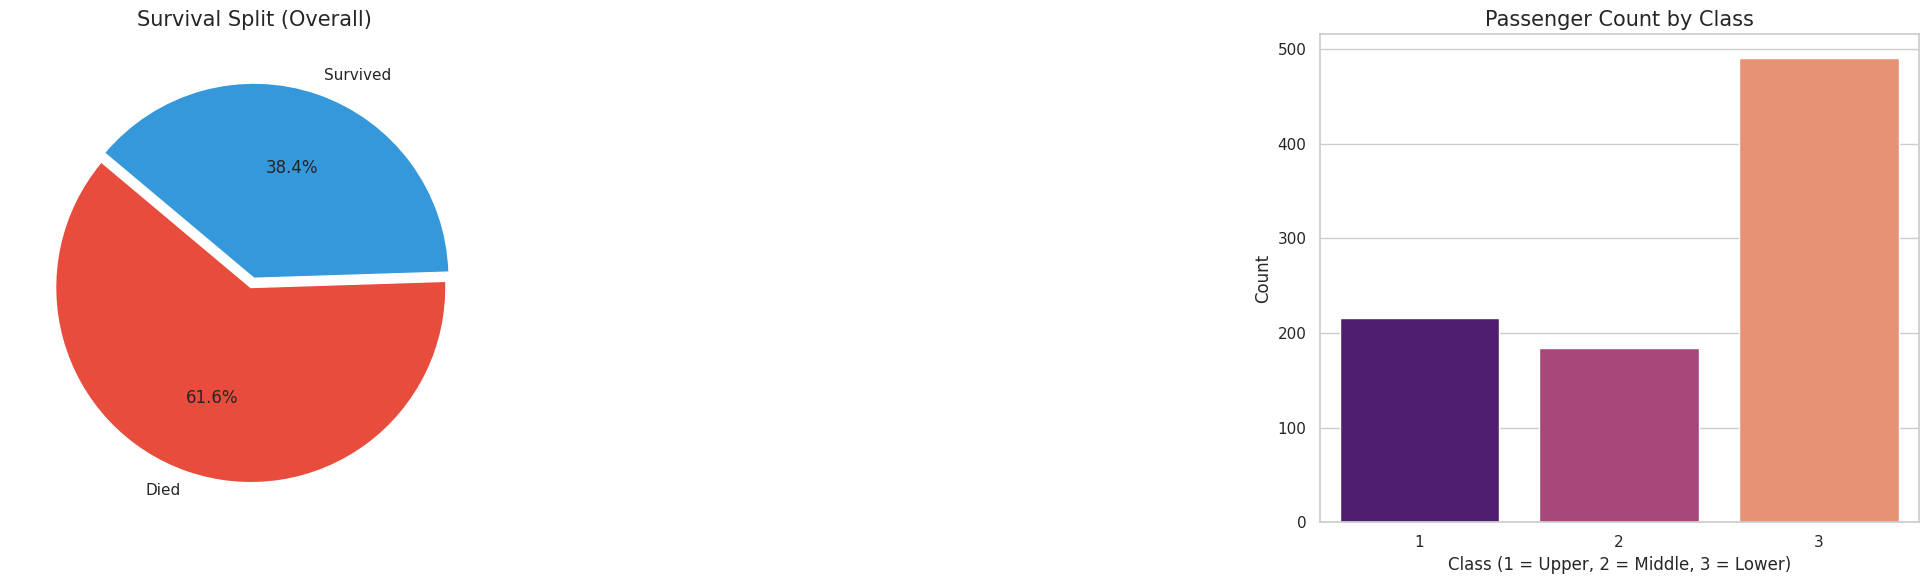

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



print("Statistical Summary of Numerical Features:")
print(DataSet[['Age', 'Fare']].describe())


sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 6))


plt.subplot(1, 3, 1)
survival_counts = DataSet['Survived'].value_counts()
plt.pie(survival_counts,
        labels=['Died', 'Survived'],
        autopct='%1.1f%%',
        colors=['#e74c3c','#3498db'], # Red for Died, Blue for Survived
        startangle=140,
        explode=(0.05, 0))
plt.title('Survival Split (Overall)', fontsize=15)


plt.subplot(1, 3, 3)
sns.countplot(x='Pclass', data=DataSet, palette='magma')
plt.title('Passenger Count by Class', fontsize=15)
plt.xlabel('Class (1 = Upper, 2 = Middle, 3 = Lower)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipython-input-415875481.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=DataSet, palette='viridis', capsize=.1)


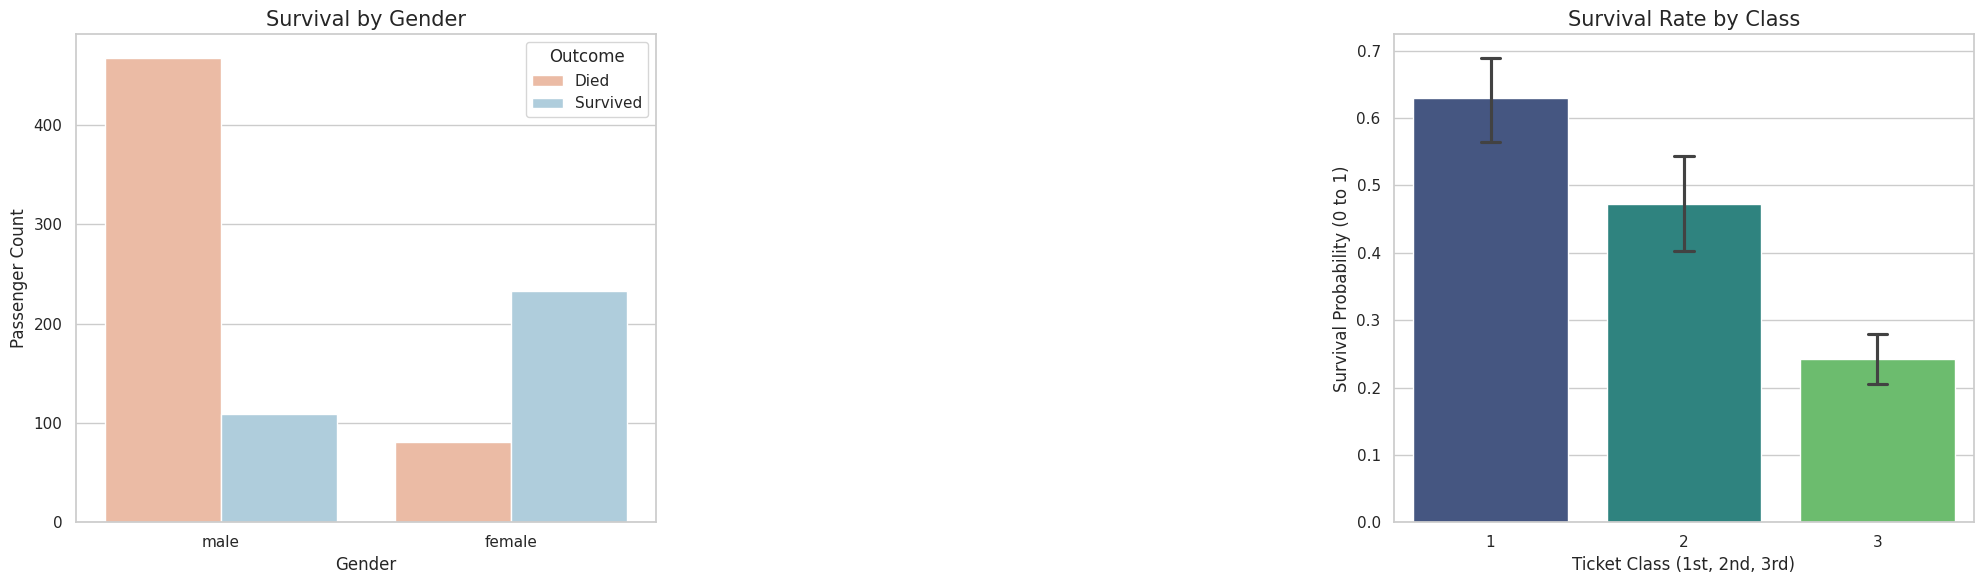

In [29]:
plt.figure(figsize=(20, 6))


plt.subplot(1, 3, 1)
sns.countplot(x='Sex', hue='Survived', data=DataSet, palette='RdBu')
plt.title('Survival by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.legend(title='Outcome', labels=['Died', 'Survived'])




plt.subplot(1, 3, 3)
sns.barplot(x='Pclass', y='Survived', data=DataSet, palette='viridis', capsize=.1)
plt.title('Survival Rate by Class', fontsize=15)
plt.xlabel('Ticket Class (1st, 2nd, 3rd)', fontsize=12)
plt.ylabel('Survival Probability (0 to 1)', fontsize=12)

plt.tight_layout()
plt.show()

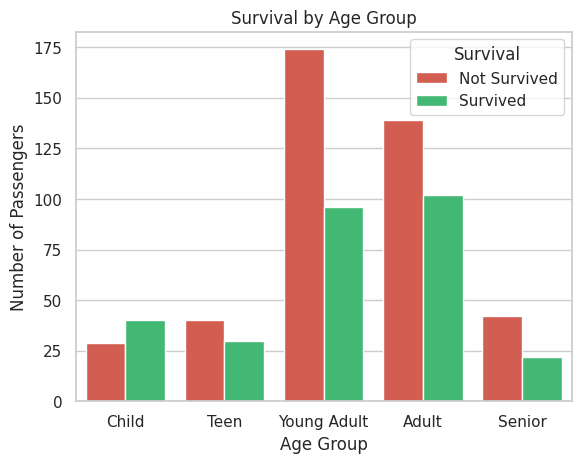

In [35]:
age_bins = [0, 12, 18, 30, 50, 80]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
DataSet['AgeGroup'] = pd.cut(DataSet['Age'], bins=age_bins, labels=age_labels)

sns.countplot(x='AgeGroup', hue='Survived', data=DataSet, palette=['#e74c3c', '#2ecc71'])

plt.title('Survival by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')


plt.legend(title='Survival', labels=['Not Survived', 'Survived'])

plt.show()

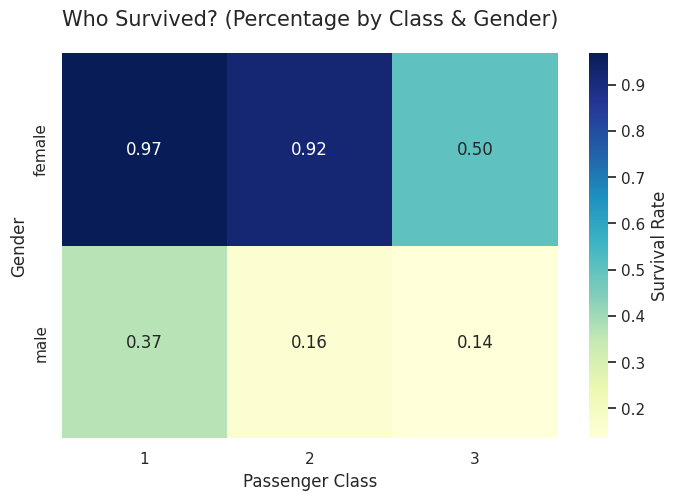

In [31]:

survival_matrix = DataSet.pivot_table(values='Survived', index='Sex', columns='Pclass')

plt.figure(figsize=(8, 5))
sns.heatmap(survival_matrix, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Survival Rate'})
plt.title('Who Survived? (Percentage by Class & Gender)', fontsize=15, pad=20)
plt.ylabel('Gender')
plt.xlabel('Passenger Class')
plt.show()

/tmp/ipython-input-69430750.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilyType', y='Survived', data=DataSet, order=['Alone', 'Small (2-4)', 'Large (5+)'], palette='Set2')


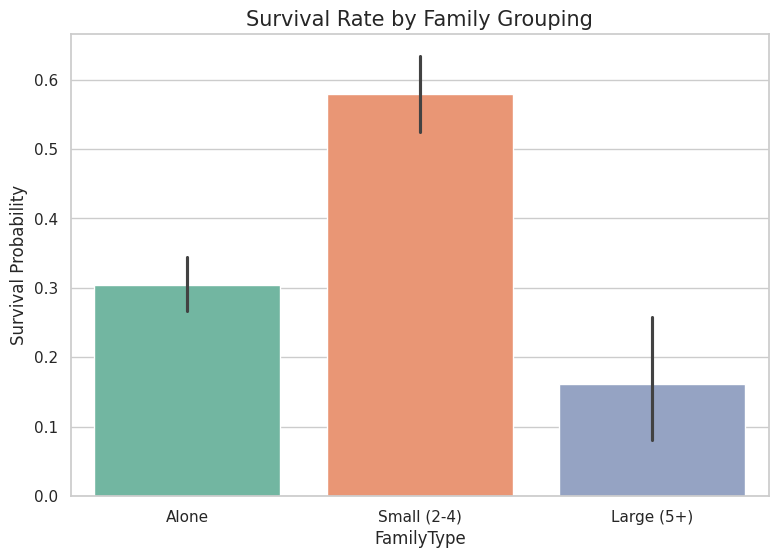

In [33]:
DataSet['FamilySize'] = DataSet['SibSp'] + DataSet['Parch'] + 1

def categorize_family(size):
    if size == 1: return 'Alone'
    elif size <= 4: return 'Small (2-4)'
    else: return 'Large (5+)'

DataSet['FamilyType'] = DataSet['FamilySize'].apply(categorize_family)

plt.figure(figsize=(9, 6))
sns.barplot(x='FamilyType', y='Survived', data=DataSet, order=['Alone', 'Small (2-4)', 'Large (5+)'], palette='Set2')
plt.title('Survival Rate by Family Grouping', fontsize=15)
plt.ylabel('Survival Probability')
plt.show()